In [1]:
import pandas as pd
import numpy as np

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
contact_data_pre_vs_unb=pd.read_csv('../../../data/intra_protein_contacts/state_specific_contacts/UNIQ_CONTACTS_DATA_PRE_VS_UNB.csv',
                                    index_col=0)
contact_data_pre_vs_unb

,Ri,Ri region,Rj,Rj region,Unique to PRE or UNB
0,4,M Nterm,9,M Nterm,PRE
1,4,M Nterm,39,M L3,PRE
2,5,M Nterm,9,M Nterm,PRE
3,8,M Nterm,12,M Nterm,PRE
4,10,M Nterm,36,M B1,PRE
...,...,...,...,...,...
14,122,R Ext Cterm,123,R Ext Cterm,PRE
15,122,R Ext Cterm,124,R Ext Cterm,PRE
16,123,R Ext Cterm,124,R Ext Cterm,PRE
17,123,R Ext Cterm,125,R Ext Cterm,PRE


In [3]:
pre_cont=contact_data_pre_vs_unb[contact_data_pre_vs_unb['Unique to PRE or UNB']=='PRE']
unb_cont=contact_data_pre_vs_unb[contact_data_pre_vs_unb['Unique to PRE or UNB']=='UNB']



In [4]:
pair_pre=[]
for fr_res, to_res, fr_dom, to_dom in zip(pre_cont['Ri'], pre_cont['Rj'],
                                         pre_cont['Ri region'], pre_cont['Rj region']):
    if 'HP' in fr_dom or 'HP' in to_dom:
        pair_pre.append([fr_res, to_res])

pair_unb=[]
for fr_res, to_res, fr_dom, to_dom in zip(unb_cont['Ri'], unb_cont['Rj'],
                                         unb_cont['Ri region'], unb_cont['Rj region']):
    if 'HP' in fr_dom or 'HP' in to_dom:
        pair_unb.append([fr_res, to_res])

In [5]:
pair_pre

[[23, 51], [35, 63], [47, 52], [48, 70], [49, 52], [49, 70]]

In [6]:
pair_unb

[[24, 32], [35, 49], [52, 63], [58, 66], [102, 108]]

In [7]:
spacer_pos=[24,0,0,0,47,48,49,0,0,0,0,0,102]

In [8]:
def hanging_line(point1, point2):
    import numpy as np

    a = (point2[1] - point1[1])/(np.cosh(point2[0]) - np.cosh(point1[0]))
    b = point1[1] - a*np.cosh(point1[0])
    x = np.linspace(point1[0], point2[0], 100)
    y = a*np.cosh(x) + b

    return (x,y)
def new_parabola_join(p_A,p_B,scaling_factor):
    if p_A<p_B:
        x_points=np.arange(p_A, p_B, 0.001)
    else:
        x_points=np.arange(p_B, p_A, 0.001)
    
    y_points=[]
    for i in x_points:
        y_points.append(((i-p_A)*(i-p_B))*scaling_factor)
    
    return x_points, y_points

pock_resi= [19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]


In [9]:
pair_pre_corr=[[52,47],[52,49],[70,48],[70,49]]
pair_pre_intra_corr=[[35,63],[51,23]]

pair_unb_corr=[[32,24],[35,49],[108,102]]
pair_unb_intra_corr=[[52,63], [66,58]]


all_res_unb_pre_to=list(set([i[1] for i in pair_pre_corr]+[i[1] for i in pair_unb_corr]))
all_res_unb_pre_fr=pock_resi

node_point_fr=[pock_resi.index(i) for i in pock_resi]
node_point_to=[spacer_pos.index(i) for i in all_res_unb_pre_to]


In [10]:
node_point_A=[pock_resi.index(i[0]) for i in pair_pre_corr]
node_point_B=[spacer_pos.index(i[1]) for i in pair_pre_corr]

node_point_intra_A=[pock_resi.index(i[0]) for i in pair_pre_intra_corr]
node_point_intra_B=[pock_resi.index(i[1]) for i in pair_pre_intra_corr]



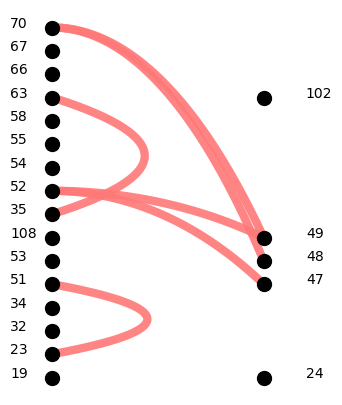

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))




counter=0
for i,j in zip(node_point_A, node_point_B):
    counter=counter+1
    
    point1 = [0,i+0]
    point2 = [1,j+0]
    x,y = hanging_line(point1, point2)

    
    ax.plot(x,y, lw=6, color='#FF7878',alpha=0.9)
    
# counter=0
# for i,j in zip(node_point_A_unb, node_point_B_unb):
#     counter=counter+1
#     point1 = [0,i+10]
#     point2 = [1,j]
#     x,y = hanging_line(point1, point2)

    
#     ax.plot(x,y, lw=6, color='#5A91FF',alpha=0.9)

# intra connection 7-12 + 0.07 as scaling
parabola_connect=new_parabola_join(12+0,7+0,0.07)
ax.plot([-i for i in parabola_connect[1]], 
         [i for i in parabola_connect[0]], 
        lw=6, color='#FF7878',alpha=0.9 )

# intra connection 4-1 + 0.2 as scaling
parabola_connect=new_parabola_join(4+0,1+0,0.2)
ax.plot([-i for i in parabola_connect[1]], 
         [i for i in parabola_connect[0]], 
        lw=6, color='#FF7878',alpha=0.9 )

counter=0
for i in node_point_fr:
    counter=counter+1
    point1 = [0,i+0]
    
    ax.plot(point1[0], point1[1], 'o', color='black',markersize=10)
    ax.text(point1[0]-0.2,point1[1],"%d"%all_res_unb_pre_fr[counter-1]) 
    

counter=0
for j in node_point_to:
    counter=counter+1
    point2 = [1,j+0]
    
    ax.plot(point2[0], point2[1], 'o',color='black',markersize=10)
    ax.text(point2[0]+0.2,point2[1],"%d"%all_res_unb_pre_to[counter-1]) 
    






ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])

plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/BP_associated_contacts_PRE.png', dpi=450,
           bbox_inches='tight', transparent=True)

In [12]:
node_point_A=[pock_resi.index(i[0]) for i in pair_unb_corr]
node_point_B=[spacer_pos.index(i[1]) for i in pair_unb_corr]

node_point_intra_A=[pock_resi.index(i[0]) for i in pair_unb_intra_corr]
node_point_intra_B=[pock_resi.index(i[1]) for i in pair_unb_intra_corr]



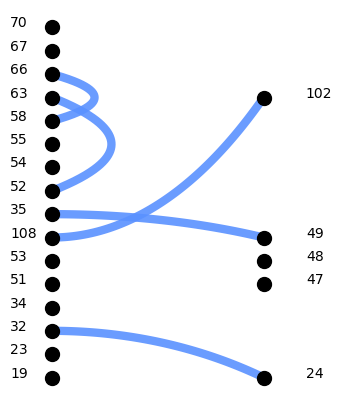

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))




counter=0
for i,j in zip(node_point_A, node_point_B):
    counter=counter+1
    
    point1 = [0,i+0]
    point2 = [1,j]
    x,y = hanging_line(point1, point2)

    
    ax.plot(x,y, lw=6, color='#5A91FF',alpha=0.9)
    
# counter=0
# for i,j in zip(node_point_A_unb, node_point_B_unb):
#     counter=counter+1
#     point1 = [0,i+10]
#     point2 = [1,j]
#     x,y = hanging_line(point1, point2)

    
#     ax.plot(x,y, lw=6, color='#5A91FF',alpha=0.9)

# intra connection 8-12 + 0.07 as scaling
parabola_connect=new_parabola_join(8+0,12+0,0.07)
ax.plot([-i for i in parabola_connect[1]], 
         [i for i in parabola_connect[0]], 
        lw=6, color='#5A91FF',alpha=0.9 )

# intra connection 13-11 + 0.2 as scaling
parabola_connect=new_parabola_join(13+0,11+0,0.2)
ax.plot([-i for i in parabola_connect[1]], 
         [i for i in parabola_connect[0]], 
        lw=6, color='#5A91FF',alpha=0.9 )

counter=0
for i in node_point_fr:
    counter=counter+1
    point1 = [0,i+0]
    
    ax.plot(point1[0], point1[1], 'o', color='black',markersize=10)
    ax.text(point1[0]-0.2,point1[1],"%d"%all_res_unb_pre_fr[counter-1]) 
    

counter=0
for j in node_point_to:
    counter=counter+1
    point2 = [1,j]
    
    ax.plot(point2[0], point2[1], 'o',color='black',markersize=10)
    ax.text(point2[0]+0.2,point2[1],"%d"%all_res_unb_pre_to[counter-1]) 
    






ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])

plt.savefig('../../../plots/intra_protein_contacts/state_specific_contacts/BP_associated_contacts_UNB.png', dpi=450,
           bbox_inches='tight', transparent=True)

In [14]:
contact_data_pre_vs_bnd=pd.read_csv('../../../data/intra_protein_contacts/state_specific_contacts/UNIQ_CONTACTS_DATA_PRE_VS_BND.csv',
                                    index_col=0)
contact_data_pre_vs_bnd

,Ri,Ri region,Rj,Rj region,Unique to PRE or BND
0,4,M Nterm,9,M Nterm,PRE
1,4,M Nterm,39,M L3,PRE
2,5,M Nterm,9,M Nterm,PRE
3,8,M Nterm,12,M Nterm,PRE
4,10,M Nterm,36,M B1,PRE
5,17,R H2,105,R L7,PRE
6,23,HP1,51,HP1,PRE
7,23,HP1,108,HP1,PRE
8,24,R H2,103,R L7,PRE
9,24,R H2,107,R L7,PRE


In [15]:
bnd_cont=contact_data_pre_vs_bnd[contact_data_pre_vs_bnd['Unique to PRE or BND']=='BND']



In [16]:
pair_bnd=[]
for fr_res, to_res, fr_dom, to_dom in zip(bnd_cont['Ri'], bnd_cont['Rj'],
                                         bnd_cont['Ri region'], bnd_cont['Rj region']):
    if 'HP' in fr_dom or 'HP' in to_dom:
        pair_bnd.append([fr_res, to_res])

In [17]:
pair_bnd

[[24, 32], [35, 49], [58, 66], [102, 108]]

In [18]:
pair_bnd_corr=[(32, 24),(35, 49),(108, 102)]
pair_bnd_intra_corr=[(58, 66)]
pair_bnd_corr_p62_cont_res=[19,23,32,34,51,52,53,54,55,63,66,67,70,108]
node_point_A=[pock_resi.index(i[0]) for i in pair_bnd_corr]
node_point_B=[spacer_pos.index(i[1]) for i in pair_bnd_corr]

node_point_A_p62_cont_res=[pock_resi.index(i) for i in pair_bnd_corr_p62_cont_res]

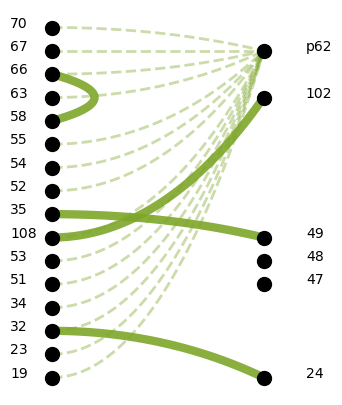

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))




counter=0
for i,j in zip(node_point_A, node_point_B):
    counter=counter+1
    
    point1 = [0,i+0]
    point2 = [1,j]
    x,y = hanging_line(point1, point2)

    
    ax.plot(x,y, lw=6, color='#7DA629',alpha=0.9)

for i in node_point_A_p62_cont_res:
    point1 = [0,i+0]
    point2 = [1,14] # to p62
    x,y = hanging_line(point1, point2)
    ax.plot(x,y, lw=2, color='#7DA629',alpha=0.4, ls='--')
    


#intra connection 11-13 + 0.2 as scaling
parabola_connect=new_parabola_join(11+0,13+0,0.2)
ax.plot([-i for i in parabola_connect[1]], 
         [i for i in parabola_connect[0]], 
        lw=6, color='#7DA629',alpha=0.9 )



counter=0
for i in node_point_fr:
    counter=counter+1
    point1 = [0,i+0]
    
    ax.plot(point1[0], point1[1], 'o', color='black',markersize=10)
    ax.text(point1[0]-0.2,point1[1],"%d"%all_res_unb_pre_fr[counter-1]) 
    

counter=0
for j in node_point_to:
    counter=counter+1
    point2 = [1,j]
    
    ax.plot(point2[0], point2[1], 'o',color='black',markersize=10)
    ax.text(point2[0]+0.2,point2[1],"%d"%all_res_unb_pre_to[counter-1]) 
    




ax.plot(1,14, 'o',color='black',markersize=10)
ax.text(1+0.2,14,'p62')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])

plt.savefig('../../../data/intra_protein_contacts/state_specific_contacts/BP_associated_contacts_BND_COMPARED_WITH_pre.png', dpi=450,
           bbox_inches='tight', transparent=True)